# Modeling
## 1: Importing Libraries and Loading the Clean Dataset

Import the main Python libraries needed for data handling, visualization, preprocessing, machine learning and model evaluation. 
Pandas and NumPy are used for data manipulation, while Matplotlib and Seaborn are used for visualizations.

Also imports regression and classification models from scikit-learn, along with scaling and evaluation metrics.
The cleaned BMW dataset is then loaded from the saved CSV file, the `Date` column is converted to datetime format, and the data is sorted chronologically. 
Sorting by date is important because the model should learn from earlier records and be tested on later records.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv("Data\Clean\Final_BMW_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()


,Date,Adj_Close,Close,High,Low,Open,Volume,OHLC_flag,Daily_Return,Price_Range,Open_Close_Diff,Volume_Change
0,1996-11-08,8.100290,18.171000,18.209999,18.171000,18.209999,767000,0,0.000000,0.039000,-0.039000,0.000000
1,1996-11-11,8.078445,18.122000,18.200001,18.082001,18.190001,260000,0,-0.002697,0.118000,-0.068001,-0.661017
2,1996-11-12,8.139520,18.259001,18.327999,18.091999,18.160999,1066000,0,0.007560,0.236000,0.098001,3.100000
3,1996-11-13,8.126592,18.230000,18.344000,18.190001,18.344000,793000,0,-0.001588,0.153999,-0.114000,-0.256098
4,1996-11-14,8.152893,18.289000,18.289000,18.132000,18.205000,351000,0,0.003236,0.157000,0.084000,-0.557377


## 2: Feature Engineering for Modelling

**Creates additional modelling features from the cleaned dataset.**
 - Lag features are created for closing price, volume and daily return using values from the previous one, two and three days. 
 - These lagged values help the models learn from recent historical behavior.

Rolling features are also created using past data only.
 - The 5-day and 10-day rolling averages of closing price show short-term price trends, while the 5-day rolling volatility captures recent variation in daily returns.
 - The code shifts rolling calculations by one day to reduce data leakage, meaning the model does not accidentally use future information.

Two target variables are then created. 
- `Target_Close` is the next day's closing price for regression.
- `Target_Direction` shows whether the next day's close is higher than the current close for classification.

Missing or infinite values are removed so the final modelling dataset is clean and ready for training.


In [ ]:
# Feature Engineering for Modelling
dt= df.copy()

# Lag features
for lag in [1, 2, 3]:
    dt[f'Close_lag{lag}'] = dt['Close'].shift(lag)
    dt[f'Volume_lag{lag}'] = dt['Volume'].shift(lag)
    dt[f'Daily_Return_lag{lag}'] = dt['Daily_Return'].shift(lag)

# Rolling features (using only past data, shifted by 1 to avoid leakage)
dt['Close_roll5'] = dt['Close'].shift(1).rolling(5).mean()
dt['Close_roll10'] = dt['Close'].shift(1).rolling(10).mean()
dt['Volatility_roll5'] = dt['Daily_Return'].shift(1).rolling(5).std()

# Targets
dt['Target_Close'] = dt['Close'].shift(-1)
dt['Target_Direction'] = (dt['Target_Close'] > dt['Close']).astype(int)

dt = dt.replace([np.inf, -np.inf], np.nan)
dt = dt.dropna().reset_index(drop=True)
print('Final modelling dataset shape:', dt.shape)
dt.head()

Final modelling dataset shape: (6962, 26)


,Date,Adj_Close,Close,High,Low,Open,Volume,OHLC_flag,Daily_Return,Price_Range,...,Volume_lag2,Daily_Return_lag2,Close_lag3,Volume_lag3,Daily_Return_lag3,Close_roll5,Close_roll10,Volatility_roll5,Target_Close,Target_Direction
0,1996-11-22,8.208170,18.413000,18.413000,18.184000,18.230000,312000,0,0.007882,0.229000,...,546000.0,-0.015800,18.544001,442000.0,0.004224,18.393600,18.3039,0.009178,18.987000,1
1,1996-11-25,8.464046,18.987000,18.987000,18.504999,18.504999,1040000,0,0.031174,0.482000,...,286000.0,0.000986,18.250999,546000.0,-0.015800,18.388600,18.3281,0.009119,19.292999,1
2,1996-11-26,8.600456,19.292999,19.572001,19.075001,19.075001,2015000,0,0.016116,0.497000,...,312000.0,0.007882,18.268999,286000.0,0.000986,18.492800,18.4146,0.016884,19.124001,0
3,1996-11-27,8.525121,19.124001,19.252001,19.105000,19.232000,455000,0,-0.008760,0.147001,...,1040000.0,0.031174,18.413000,312000.0,0.007882,18.642599,18.5180,0.017454,19.667000,1
4,1996-11-28,8.767179,19.667000,19.714001,19.153999,19.155001,923000,0,0.028394,0.560001,...,2015000.0,0.016116,18.987000,1040000.0,0.031174,18.817200,18.6074,0.015182,19.691999,1


## 3: Selecting Model Features

**This defines the input features that will be used to train the models.** 
The selected features include original stock market variables such as Open, High, Low, Close, Adjusted Close and Volume, along with engineered variables such as daily return, price range, volume change, lag features, rolling averages and rolling volatility.

The feature matrix `X` is created from these columns. 
The code also prints the number of features and displays summary statistics for each feature. 
*This helps confirm that the model inputs are correctly selected and gives a quick view of their ranges and distributions.*


In [6]:
feature_cols = ['Open','High','Low','Close','Adj_Close','Volume',
                 'Price_Range','Open_Close_Diff','Volume_Change','Daily_Return',
                 'Close_lag1','Close_lag2','Close_lag3',
                 'Volume_lag1','Volume_lag2','Volume_lag3',
                 'Daily_Return_lag1','Daily_Return_lag2','Daily_Return_lag3',
                 'Close_roll5','Close_roll10','Volatility_roll5']

X = dt[feature_cols]
print('Number of features:', len(feature_cols))
X.describe().T

Number of features: 22


,count,mean,std,min,25%,50%,75%,max
Open,6962.0,5.716904e+01,2.522630e+01,17.280001,3.482250e+01,5.295000e+01,7.990000e+01,1.233000e+02
High,6962.0,5.783673e+01,2.538638e+01,17.815001,3.525000e+01,5.409500e+01,8.069000e+01,1.237500e+02
Low,6962.0,5.643699e+01,2.502985e+01,16.000000,3.434125e+01,5.203000e+01,7.908500e+01,1.203500e+02
Close,6962.0,5.714748e+01,2.521741e+01,17.040001,3.476000e+01,5.312500e+01,7.985750e+01,1.226000e+02
Adj_Close,6962.0,3.662471e+01,2.365387e+01,8.065074,1.660727e+01,2.961650e+01,5.361188e+01,1.080590e+02
Volume,6962.0,2.124364e+06,1.474298e+06,0.000000,1.209103e+06,1.809510e+06,2.655062e+06,2.871954e+07
Price_Range,6962.0,1.399742e+00,8.425692e-01,0.000000,8.442497e-01,1.250000e+00,1.760002e+00,1.016000e+01
Open_Close_Diff,6962.0,-2.156309e-02,9.275780e-01,-8.239998,-4.800034e-01,0.000000e+00,4.400024e-01,5.549995e+00
Volume_Change,6962.0,1.051086e-01,1.117679e+00,-1.000000,-2.411894e-01,-1.230675e-02,2.862264e-01,7.047059e+01
Daily_Return,6962.0,2.973679e-04,2.085021e-02,-0.131850,-9.974667e-03,0.000000e+00,1.045199e-02,1.483843e-01


## 4: Splitting the Data into Training and Testing Sets

**Splits the dataset into training and testing sets using an 80 percent to 20 percent split.**
Because stock data is time-based, the split is done in chronological order instead of randomly. 
The earlier 80 percent of records are used for training, while the later 20 percent are used for testing.

Separate target variables are prepared for the **two modelling tasks**: 
 - *Predicting the next day's closing price.* 
 - *Predicting whether the next day's direction is up or down.* 

The dates for the training and testing periods are also stored so the results can be plotted later.

**The features are scaled using `StandardScaler`.**
Scaling is especially useful for linear and logistic regression because these models are affected by differences in feature magnitude. 
Tree-based models do not require scaling, but the original unscaled data is still available for them.


In [ ]:
#Spliting Data into training and testing data
split_idx = int(len(dt) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_reg_train, y_reg_test = dt['Target_Close'].iloc[:split_idx], dt['Target_Close'].iloc[split_idx:]
y_clf_train, y_clf_test = dt['Target_Direction'].iloc[:split_idx], dt['Target_Direction'].iloc[split_idx:]

train_dates = dt['Date'].iloc[:split_idx]
test_dates = dt['Date'].iloc[split_idx:]

print('Train period:', train_dates.min().date(), 'to', train_dates.max().date())
print('Test period:', test_dates.min().date(), 'to', test_dates.max().date())
print('Train size:', len(X_train), '| Test size:', len(X_test))

# Scale features (helps Linear/Logistic Regression; tree models don't need it but it's harmless)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train period: 1996-11-22 to 2019-06-19
Test period: 2019-06-20 to 2024-12-27
Train size: 5569 | Test size: 1393


## 5: Training and Evaluating Regression Models

Trains three regression models to predict the next day's BMW closing price: **Linear Regression, Random Forest Regressor** and **Gradient Boosting Regressor.**

Linear Regression is trained using the scaled features, while the tree-based models are trained using the original feature values. 
After each model makes predictions on the test set, the predictions are evaluated using MAE, RMSE and R-squared. MAE and RMSE measure prediction error, so lower values are better.
R-squared measures how well the model explains the variation in the target, so higher values are better.

*The results are stored in a summary table so the regression models can be compared easily.*

In [8]:
# Regression
reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
}

reg_results = {}
reg_preds = {}

for name, model in reg_models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_reg_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_reg_train)
        preds = model.predict(X_test)

    mae = mean_absolute_error(y_reg_test, preds)
    rmse = np.sqrt(mean_squared_error(y_reg_test, preds))
    r2 = r2_score(y_reg_test, preds)

    reg_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    reg_preds[name] = preds

reg_results_df = pd.DataFrame(reg_results).T
reg_results_df

,MAE,RMSE,R2
Linear Regression,1.041898,1.458501,0.991196
Random Forest,1.169225,1.624340,0.989080
Gradient Boosting,1.359116,1.857123,0.985725


## 6: Visualizing Actual vs Predicted Closing Prices

**Plots the actual next-day closing prices against the predicted prices for each regression model.** Each subplot shows one model, making it easier to compare how closely each model follows the real test data.

This visualization helps evaluate model performance beyond numerical metrics. 

*A good model should produce a prediction line that closely follows the actual closing price line, especially during major upward or downward movements.*


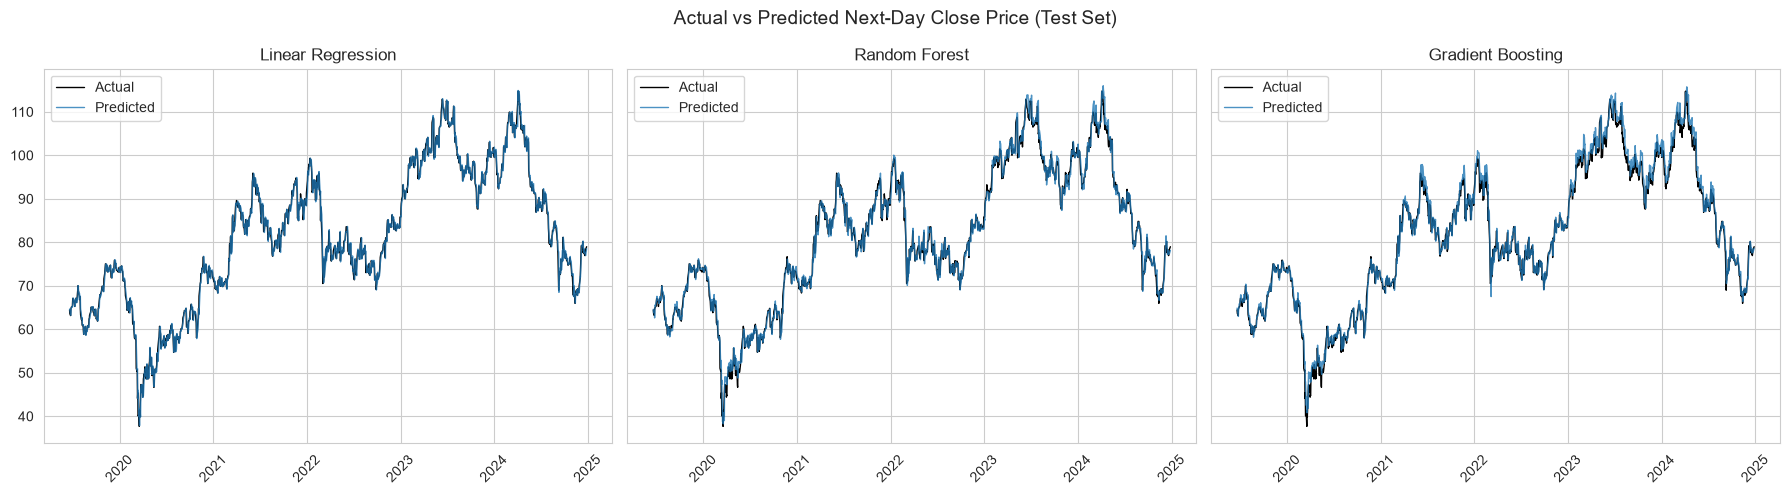

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)
for ax, (name, preds) in zip(axes, reg_preds.items()):
    ax.plot(test_dates.values, y_reg_test.values, label='Actual', color='black', linewidth=1)
    ax.plot(test_dates.values, preds, label='Predicted', linewidth=1, alpha=0.8)
    ax.set_title(name)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Actual vs Predicted Next-Day Close Price (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

## 7: Regression Feature Importance

Displays feature importance for the tree-based regression models: **Random Forest and Gradient Boosting.** Feature importance shows which input variables contributed most to each model's predictions.

The features are sorted from most important to least important and displayed as horizontal bar charts. This helps explain which variables the models relied on most when predicting the next day's closing price. Linear Regression is not included here because it does not provide feature importance in the same way as tree-based models.


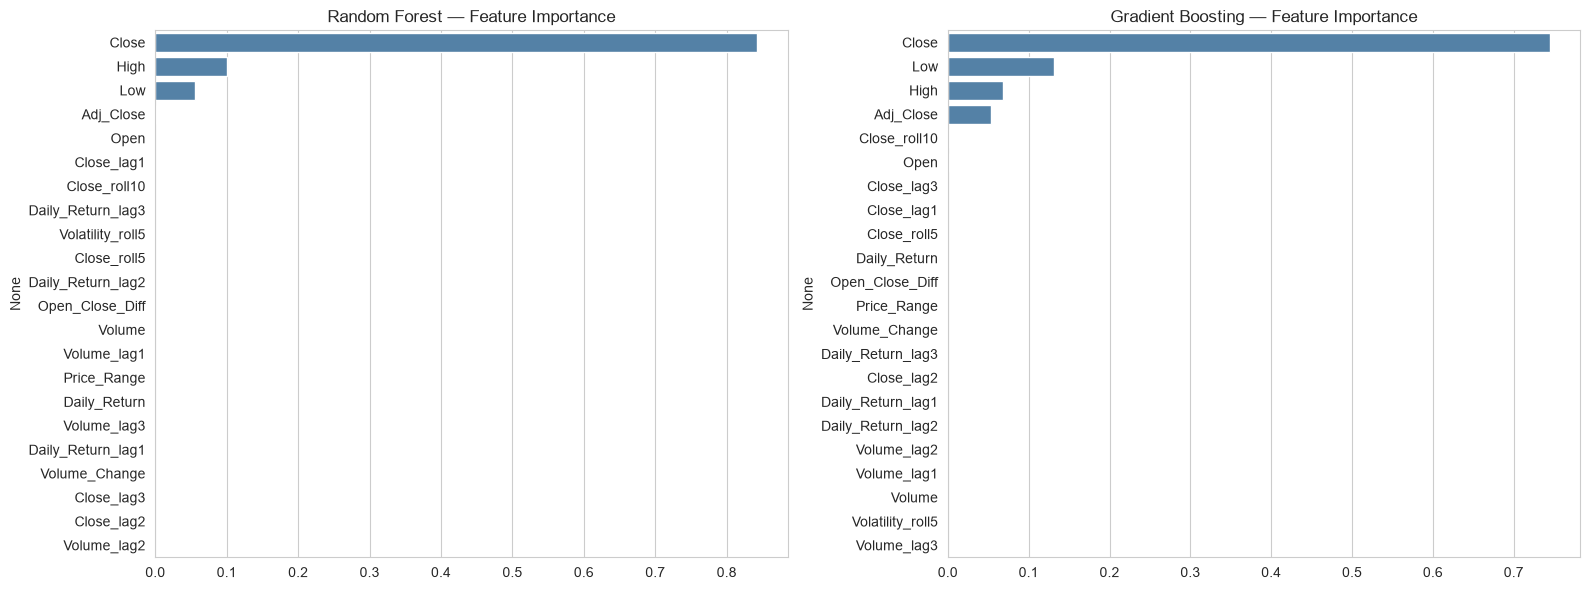

In [10]:
# Feature importance (Tree-Based Regression Models)
fig, axes = plt.subplots(1, 2, figsize=(16,6))
for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = reg_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    sns.barplot(x=importances.values, y=importances.index, ax=ax, color='steelblue')
    ax.set_title(f'{name} — Feature Importance')
plt.tight_layout()
plt.show()

## 8: Checking Classification Class Balance

**Begins the classification section, where the goal is to predict whether the next day's closing price will move up or down.**

Before training classification models, the code checks the balance between the two classes in the training data. Class balance is important because if one class appears much more often than the other, a model may become biased toward predicting the majority class.

In [11]:
# Classification -Predicting Next Day Direction(UP/DOWN)
print('Class balance (train):')
print(y_clf_train.value_counts(normalize=True).rename({0:'Down', 1:'Up'}))

Class balance (train):
Target_Direction
Down    0.509607
Up      0.490393
Name: proportion, dtype: float64


## 9: Training and Evaluating Classification Models

**Trains three classification models to predict the next day's price direction: Logistic Regression, Random Forest Classifier and Gradient Boosting Classifier.**

Logistic Regression is trained using scaled features, while the tree-based classifiers use the original feature values. Each model makes predictions on the test set and the predictions are evaluated using accuracy, precision, recall and F1-score. 
Accuracy measures overall correctness, precision measures how reliable the predicted "Up" signals are, recall measures how many actual "Up" days were detected and F1-score balances precision and recall.

*The results are stored in a comparison table so the classification models can be evaluated side by side.*


In [12]:
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
}

clf_results = {}
clf_preds = {}

for name, model in clf_models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_clf_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_clf_train)
        preds = model.predict(X_test)

    clf_results[name] = {
        'Accuracy': accuracy_score(y_clf_test, preds),
        'Precision': precision_score(y_clf_test, preds),
        'Recall': recall_score(y_clf_test, preds),
        'F1': f1_score(y_clf_test, preds)
    }
    clf_preds[name] = preds

clf_results_df = pd.DataFrame(clf_results).T
clf_results_df

,Accuracy,Precision,Recall,F1
Logistic Regression,0.490309,0.508772,0.040788,0.075521
Random Forest,0.511127,0.529070,0.383966,0.444988
Gradient Boosting,0.500359,0.513863,0.390999,0.444089


## 10: Confusion Matrix Visualization

Creates a confusion matrix for each classification model. *A confusion matrix compares the model's predicted direction with the actual direction.*

The rows represent the actual class, while the columns represent the predicted class. This makes it possible to see how many days were correctly predicted as Down or Up, as well as how many were misclassified. 

*Confusion matrices are useful because they show the types of mistakes each model is making, not just the overall accuracy.*


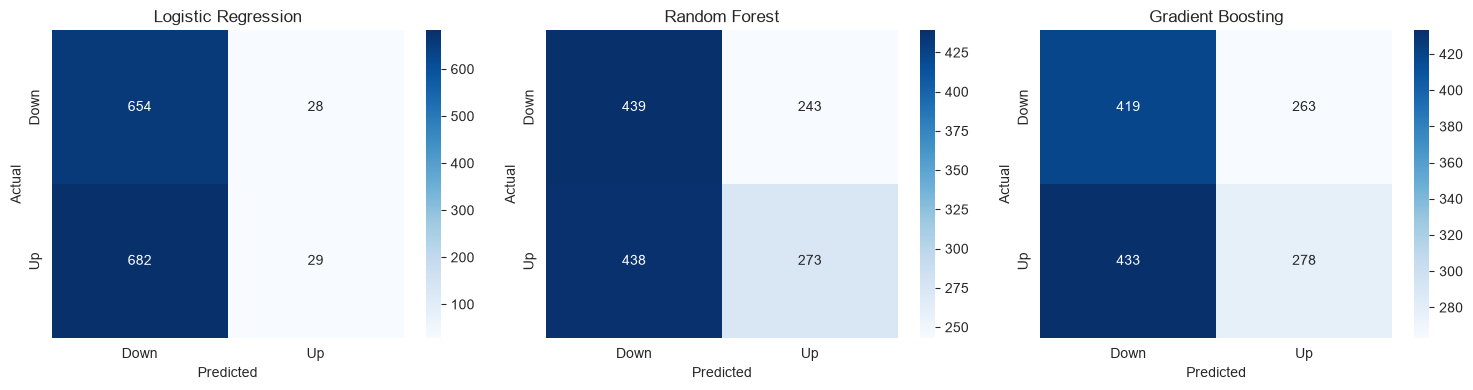

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, preds) in zip(axes, clf_preds.items()):
    cm = confusion_matrix(y_clf_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 11: Detailed Classification Reports

Prints a detailed classification report for each model. **The report includes precision, recall, F1-score, and support for both classes: Down and Up.**

T*his gives a more complete view of classification performance than accuracy alone. It is especially useful if the model performs well on one class but poorly on the other.*

In [14]:
for name, preds in clf_preds.items():
    print(f'--- {name} ---')
    print(classification_report(y_clf_test, preds, target_names=['Down','Up']))

--- Logistic Regression ---
              precision    recall  f1-score   support

        Down       0.49      0.96      0.65       682
          Up       0.51      0.04      0.08       711

    accuracy                           0.49      1393
   macro avg       0.50      0.50      0.36      1393
weighted avg       0.50      0.49      0.36      1393

--- Random Forest ---
              precision    recall  f1-score   support

        Down       0.50      0.64      0.56       682
          Up       0.53      0.38      0.44       711

    accuracy                           0.51      1393
   macro avg       0.51      0.51      0.50      1393
weighted avg       0.52      0.51      0.50      1393

--- Gradient Boosting ---
              precision    recall  f1-score   support

        Down       0.49      0.61      0.55       682
          Up       0.51      0.39      0.44       711

    accuracy                           0.50      1393
   macro avg       0.50      0.50      0.50      139

## 12: Classification Feature Importance

**Displays feature importance for the tree-based classification models: Random Forest and Gradient Boosting.**

 The bar charts show which features were most influential when predicting whether the next day's closing price would move up or down.

*Understanding feature importance helps make the classification models more interpretable. It shows whether the models are relying more on current prices, lagged values, returns, volume-related variables, or rolling trend indicators.*


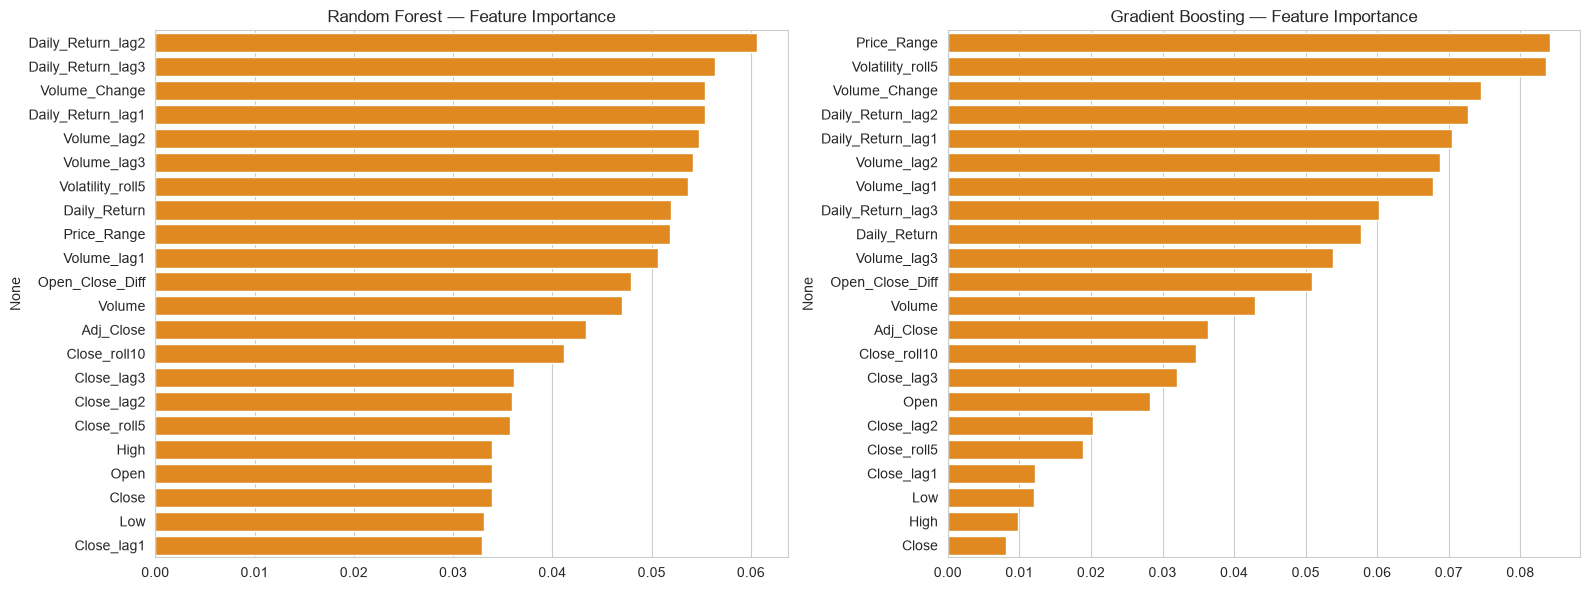

In [15]:
# Feature Importance (Tree-Based Classification Model)
fig, axes = plt.subplots(1, 2, figsize=(16,6))
for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = clf_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    sns.barplot(x=importances.values, y=importances.index, ax=ax, color='darkorange')
    ax.set_title(f'{name} — Feature Importance')
plt.tight_layout()
plt.show()


## 13: Final Model Comparison Summary

This summarizes the performance of all models. 

- *The regression results are sorted by RMSE, where lower RMSE indicates better price prediction performance.* 
- *The classification results are sorted by accuracy, where higher accuracy indicates better directional prediction performance.*

This summary makes it easier to identify the best-performing model for each task: predicting the next day's closing price and predicting whether the next day's price will move up or down.


In [16]:
# Model Comparison Summary
print('REGRESSION RESULTS (lower MAE/RMSE better, higher R2 better)')
display(reg_results_df.sort_values('RMSE'))

print('\nCLASSIFICATION RESULTS (higher is better)')
display(clf_results_df.sort_values('Accuracy', ascending=False))

REGRESSION RESULTS (lower MAE/RMSE better, higher R2 better)


,MAE,RMSE,R2
Linear Regression,1.041898,1.458501,0.991196
Random Forest,1.169225,1.624340,0.989080
Gradient Boosting,1.359116,1.857123,0.985725



CLASSIFICATION RESULTS (higher is better)


,Accuracy,Precision,Recall,F1
Random Forest,0.511127,0.529070,0.383966,0.444988
Gradient Boosting,0.500359,0.513863,0.390999,0.444089
Logistic Regression,0.490309,0.508772,0.040788,0.075521


## 13: Conclusion

**This modelling notebook compared both regression and classification approaches for predicting BMW stock behavior.** 

The regression models were used to predict the next day's closing price, while the classification models were used to predict whether the next day's price would move up or down.

From the regression results, the best-performing model was **[insert best regression model name]**, because it produced the lowest RMSE value of **[insert RMSE value]**. 
- This means it had the smallest overall prediction error when estimating the next day's closing price. 
- The MAE and R-squared values also help confirm how closely the model's predictions matched the actual test data.

For the classification task, the best-performing model was **[insert best classification model name]**, because it achieved the highest accuracy of **[insert accuracy value]**. 
The precision, recall and F1-score provide additional insight into how well the model predicted upward and downward price movements.

Overall, the results show that engineered features such as lag values, rolling averages, daily returns, volatility and price-range indicators can help machine learning models learn useful patterns from historical BMW stock data.
However, stock prices are influenced by many external factors such as market news, economic conditions, investor sentiment and global events. 
*Because of this, the models should be viewed as analytical tools for identifying patterns rather than as guaranteed predictors of future stock prices.*

In conclusion, the modelling process successfully demonstrated how historical BMW stock data can be prepared, transformed and used to build predictive models. 

*The best regression model can be used to estimate future closing prices, while the best classification model can support direction-based analysis of whether the stock is likely to move up or down.*
